# SAM AI Technologies - Data Analyst Internship

## Task 3: Data Visualization

### Objective
The objective of this task is to transform restaurant data into meaningful visualizations and identify useful patterns related to restaurant ratings, cities, cuisines, and price ranges.

### Tools Used
- Python
- Pandas
- Matplotlib

### Dataset
Zomato Restaurant Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset_url = "https://raw.githubusercontent.com/radhika-patel017/SAM-AI-Tech-Task/main/Zomato-Dataset.csv"

df = pd.read_csv(dataset_url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,3400025,Jahanpanah,India,1,Agra,"E 23, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",78.011544,27.161661,...,Indian Rupees(Rs.),No,No,No,No,3,3.9,Yellow,Good,140
1,3400341,Rangrezz Restaurant,India,1,Agra,"E-20, Shopping Arcade, Sadar Bazaar, Agra Cant...",Agra Cantt,"Agra Cantt, Agra",0.000000,0.000000,...,Indian Rupees(Rs.),No,No,No,No,2,3.5,Yellow,Good,71
2,3400005,Time2Eat - Mama Chicken,India,1,Agra,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra Cantt,"Agra Cantt, Agra",78.011608,27.160832,...,Indian Rupees(Rs.),No,No,No,No,2,3.6,Yellow,Good,94
3,3400021,Chokho Jeeman Marwari Jain Bhojanalya,India,1,Agra,"1/48, Delhi Gate, Station Road, Raja Mandi, Ci...",Civil Lines,"Civil Lines, Agra",77.998092,27.195928,...,Indian Rupees(Rs.),No,No,No,No,2,4.0,Green,Very Good,87
4,3400017,Pinch Of Spice,India,1,Agra,"23/453, Opposite Sanjay Cinema, Wazipura Road,...",Civil Lines,"Civil Lines, Agra",78.007553,27.201725,...,Indian Rupees(Rs.),No,No,No,No,3,4.2,Green,Very Good,177


In [ ]:
df.shape

(9549, 22)

In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country', 'Country Code', 'City',
       'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude',
       'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [4]:
print("Original dataset shape:", df.shape)
print("Missing cuisine values:", df["Cuisines"].isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.dropna(subset=["Cuisines"]).copy()
df.reset_index(drop=True, inplace=True)

print("Cleaned dataset shape:", df.shape)

Original dataset shape: (9549, 22)
Missing cuisine values: 9
Duplicate rows: 0
Cleaned dataset shape: (9540, 22)


In [ ]:
df.shape

(9540, 22)

In [ ]:
df[["Restaurant Name", "City", "Cuisines", "Aggregate rating", "Votes"]].head()

,Restaurant Name,City,Cuisines,Aggregate rating,Votes
0,Jahanpanah,Agra,"North Indian, Mughlai",3.9,140
1,Rangrezz Restaurant,Agra,"North Indian, Mughlai",3.5,71
2,Time2Eat - Mama Chicken,Agra,North Indian,3.6,94
3,Chokho Jeeman Marwari Jain Bhojanalya,Agra,Rajasthani,4.0,87
4,Pinch Of Spice,Agra,"North Indian, Chinese, Mughlai",4.2,177


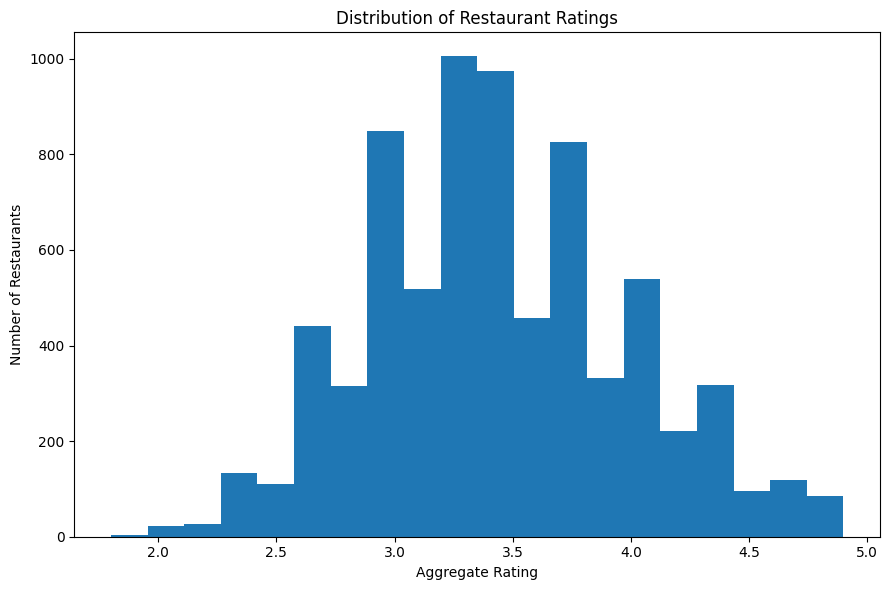

In [5]:
rated_restaurants = df[df["Aggregate rating"] > 0]

plt.figure(figsize=(9, 6))

plt.hist(
    rated_restaurants["Aggregate rating"],
    bins=20
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

### Insight - Rating Distribution

After excluding restaurants with an aggregate rating of 0, the visualization shows how valid restaurant ratings are distributed across the dataset.

Restaurant ratings are generally concentrated around the mid-to-high 3-point range.

In [ ]:
top_cities = df["City"].value_counts().head(10)

top_cities

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Guwahati,21
Bhubaneshwar,21
Lucknow,21
Ahmedabad,21


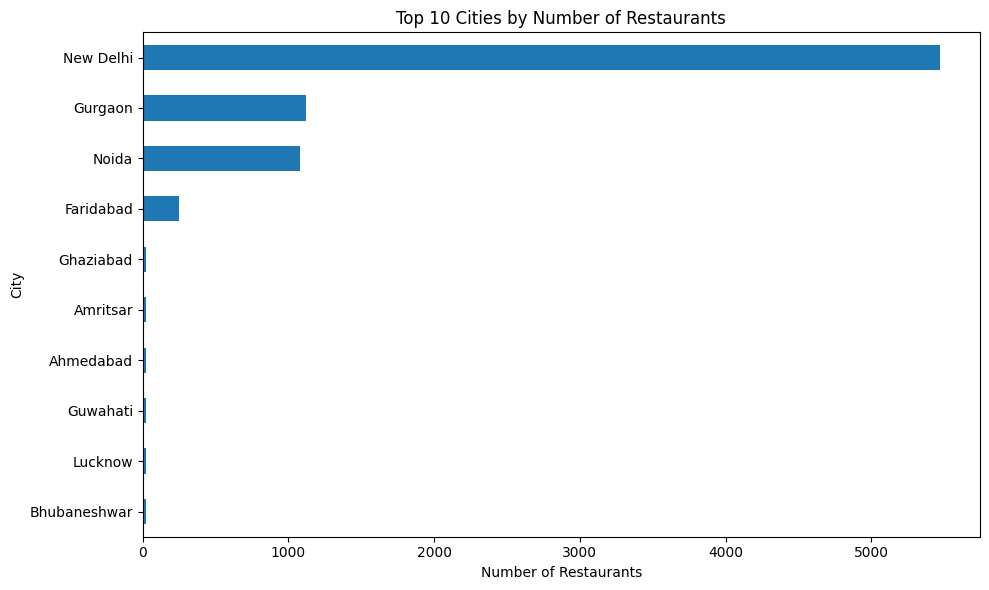

In [ ]:
plt.figure(figsize=(10, 6))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### Insight - Restaurant Distribution by City

**New Delhi** has the largest number of restaurants in the dataset with **5,473 restaurants**, followed by **Gurgaon with 1,118** and **Noida with 1,080**.

This indicates that the dataset is heavily concentrated in New Delhi compared with the other cities represented.

In [6]:
individual_cuisines = (
    df["Cuisines"]
    .str.split(",")
    .explode()
    .str.strip()
)

top_individual_cuisines = individual_cuisines.value_counts().head(10)

top_individual_cuisines

,count
Cuisines,
North Indian,3960
Chinese,2734
Fast Food,1986
Mughlai,995
Italian,764
Bakery,745
Continental,736
Cafe,703
Desserts,653


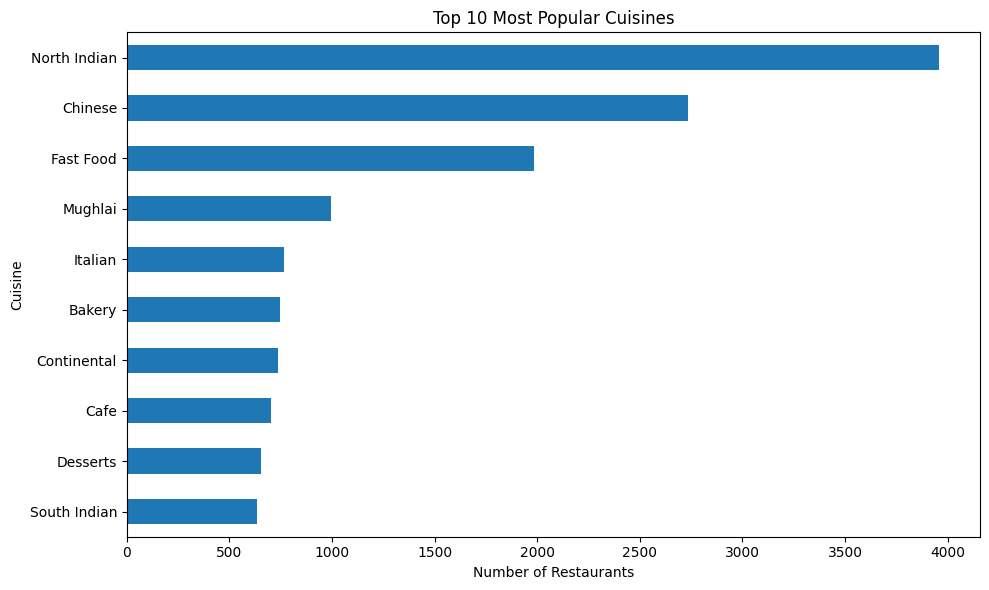

In [7]:
plt.figure(figsize=(10, 6))

top_individual_cuisines.sort_values().plot(kind="barh")

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

### Insight - Popular Cuisines

**North Indian** is the most commonly available individual cuisine in the dataset, followed by **Chinese** and **Fast Food**.

This shows that North Indian cuisine has the strongest presence among the restaurants represented in the dataset.

In [8]:
price_range_counts = df["Price range"].value_counts().sort_index()

price_range_counts

,count
Price range,
1,4438
2,3111
3,1405
4,586


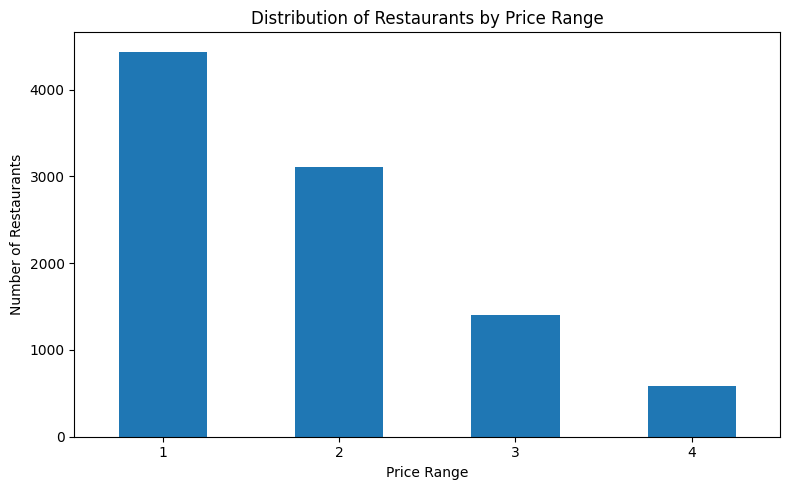

In [9]:
plt.figure(figsize=(8, 5))

price_range_counts.plot(kind="bar")

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
price_rating = (
    rated_restaurants
    .groupby("Price range")["Aggregate rating"]
    .mean()
    .round(2)
)

price_rating

,Aggregate rating
Price range,
1,3.24
2,3.38
3,3.78
4,3.89


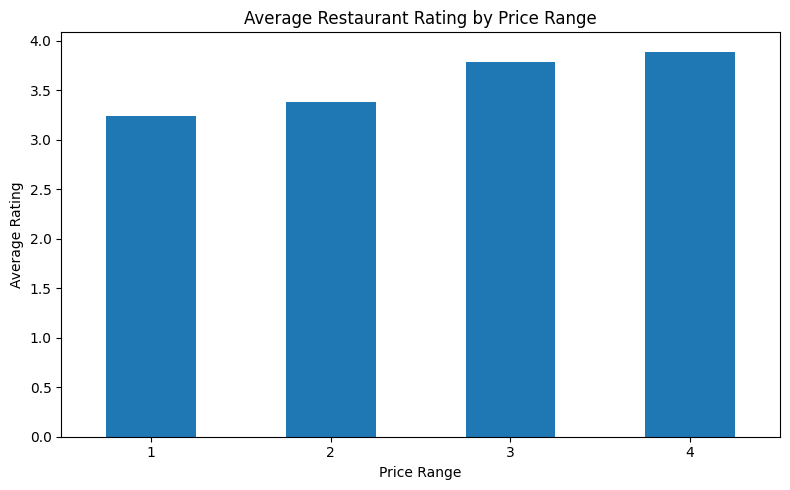

In [11]:
plt.figure(figsize=(8, 5))

price_rating.plot(kind="bar")

plt.title("Average Restaurant Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Final Insights - Task 3

The visualizations reveal several important patterns in the restaurant dataset.

**New Delhi** dominates the dataset with **5,473 restaurants**, followed by Gurgaon and Noida.

**North Indian** is the most commonly available individual cuisine, followed by Chinese and Fast Food.

Most restaurants belong to the lower price categories. **Price Range 1 contains 4,438 restaurants**, while only **586 restaurants** belong to Price Range 4.

Among rated restaurants, average ratings increase across the price ranges, from approximately **3.24 in Price Range 1** to approximately **3.89 in Price Range 4**.

This indicates an association between higher price categories and higher average ratings in this dataset. However, price alone should not be interpreted as the cause of higher ratings.

# Task 3 Conclusion

The data visualization analysis helped identify important patterns related to restaurant ratings, city distribution, cuisine popularity, and price ranges.

The results show that the dataset is strongly concentrated in New Delhi, North Indian cuisine is the most widely represented cuisine, and higher price-range restaurants tend to have somewhat higher average ratings.

Overall, the visualizations make the restaurant data easier to understand and communicate.